# DamageLens: Dataset Preparation

This notebook converts the audited raw datasets into consistent COCO instance-segmentation datasets for model training.

## Active datasets

| Dataset | Role | Output |
|---|---|---|
| Car Parts | Vehicle-part segmentation | `data/processed/car_parts` |
| CarDD | Damage-type segmentation | `data/processed/cardd` |
| Damage Severity | Damage severity segmentation | `data/processed/severity` |

Raw datasets are treated as immutable. All corrections are written under `data/processed/`.

The original `data/raw/severity` dataset is excluded because its severity labels and masks were found to be unreliable.

## Data sources

- **Car Parts Instance Segmentation v3:**  
  https://universe.roboflow.com/model-examples/car-parts-instance-segmentation/dataset/3

- **CarDD:**  
  https://cardd-ustc.github.io/

- **Damage Severity v4:**  
  https://universe.roboflow.com/sinfo-ynjd3/damage-severity-u5zwl/dataset/4

The detailed dataset audit and acceptance decisions are documented in `01_dataset_audit_and_eda.ipynb`.

### Imports

In [1]:
from pathlib import Path
import json

import pandas as pd

##  Project paths

Resolve the project root dynamically so the notebook works when launched from either the repository root or the `notebooks` directory.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_ROOT = PROJECT_ROOT / "data" / "raw"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:    {RAW_ROOT}")
print(f"Processed:   {PROCESSED_ROOT}")

Project root: E:\Projects\DamageLens
Raw data:    E:\Projects\DamageLens\data\raw
Processed:   E:\Projects\DamageLens\data\processed


##  Dataset registry

Register every input split and its corresponding processed output directory. All processed datasets will use the split names `train`, `validation`, and `test`.

In [3]:
CAR_PARTS_ROOT = RAW_ROOT / "car_parts"
CARDD_ROOT = RAW_ROOT / "cardd"
SEVERITY_ROOT = RAW_ROOT / "severity_candidate"

### Register splits

In [4]:
split_specs = [
    ("Car Parts", "train", CAR_PARTS_ROOT / "train", CAR_PARTS_ROOT / "train" / "_annotations.coco.json", PROCESSED_ROOT / "car_parts" / "train"),
    ("Car Parts", "validation", CAR_PARTS_ROOT / "valid", CAR_PARTS_ROOT / "valid" / "_annotations.coco.json", PROCESSED_ROOT / "car_parts" / "validation"),
    ("Car Parts", "test", CAR_PARTS_ROOT / "test", CAR_PARTS_ROOT / "test" / "_annotations.coco.json", PROCESSED_ROOT / "car_parts" / "test"),
    ("CarDD", "train", CARDD_ROOT / "train2017", CARDD_ROOT / "annotations" / "instances_train2017.json", PROCESSED_ROOT / "cardd" / "train"),
    ("CarDD", "validation", CARDD_ROOT / "val2017", CARDD_ROOT / "annotations" / "instances_val2017.json", PROCESSED_ROOT / "cardd" / "validation"),
    ("CarDD", "test", CARDD_ROOT / "test2017", CARDD_ROOT / "annotations" / "instances_test2017.json", PROCESSED_ROOT / "cardd" / "test"),
    ("Severity", "train", SEVERITY_ROOT / "train", SEVERITY_ROOT / "train" / "_annotations.coco.json", PROCESSED_ROOT / "severity" / "train"),
    ("Severity", "validation", SEVERITY_ROOT / "valid", SEVERITY_ROOT / "valid" / "_annotations.coco.json", PROCESSED_ROOT / "severity" / "validation"),
    ("Severity", "test", SEVERITY_ROOT / "test", SEVERITY_ROOT / "test" / "_annotations.coco.json", PROCESSED_ROOT / "severity" / "test"),
]

split_paths = pd.DataFrame(
    split_specs,
    columns=["dataset", "split", "image_directory", "annotation_file", "output_directory"],
)

split_paths

,dataset,split,image_directory,annotation_file,output_directory
0,Car Parts,train,E:\Projects\DamageLens\data\raw\car_parts\train,E:\Projects\DamageLens\data\raw\car_parts\trai...,E:\Projects\DamageLens\data\processed\car_part...
1,Car Parts,validation,E:\Projects\DamageLens\data\raw\car_parts\valid,E:\Projects\DamageLens\data\raw\car_parts\vali...,E:\Projects\DamageLens\data\processed\car_part...
2,Car Parts,test,E:\Projects\DamageLens\data\raw\car_parts\test,E:\Projects\DamageLens\data\raw\car_parts\test...,E:\Projects\DamageLens\data\processed\car_part...
3,CarDD,train,E:\Projects\DamageLens\data\raw\cardd\train2017,E:\Projects\DamageLens\data\raw\cardd\annotati...,E:\Projects\DamageLens\data\processed\cardd\train
4,CarDD,validation,E:\Projects\DamageLens\data\raw\cardd\val2017,E:\Projects\DamageLens\data\raw\cardd\annotati...,E:\Projects\DamageLens\data\processed\cardd\va...
5,CarDD,test,E:\Projects\DamageLens\data\raw\cardd\test2017,E:\Projects\DamageLens\data\raw\cardd\annotati...,E:\Projects\DamageLens\data\processed\cardd\test
6,Severity,train,E:\Projects\DamageLens\data\raw\severity_candi...,E:\Projects\DamageLens\data\raw\severity_candi...,E:\Projects\DamageLens\data\processed\severity...
7,Severity,validation,E:\Projects\DamageLens\data\raw\severity_candi...,E:\Projects\DamageLens\data\raw\severity_candi...,E:\Projects\DamageLens\data\processed\severity...
8,Severity,test,E:\Projects\DamageLens\data\raw\severity_candi...,E:\Projects\DamageLens\data\raw\severity_candi...,E:\Projects\DamageLens\data\processed\severity...


##  Validate raw paths

Preparation must stop if any image directory or COCO annotation file is missing.

In [5]:
path_check = split_paths.copy()
path_check["images_found"] = path_check["image_directory"].map(lambda path: path.is_dir())
path_check["annotations_found"] = path_check["annotation_file"].map(lambda path: path.is_file())

path_check[["dataset", "split", "images_found", "annotations_found"]]

,dataset,split,images_found,annotations_found
0,Car Parts,train,True,True
1,Car Parts,validation,True,True
2,Car Parts,test,True,True
3,CarDD,train,True,True
4,CarDD,validation,True,True
5,CarDD,test,True,True
6,Severity,train,True,True
7,Severity,validation,True,True
8,Severity,test,True,True


### Confirm structure

In [7]:
required_columns = ["images_found", "annotations_found"]
all_paths_found = path_check[required_columns].all().all()

assert all_paths_found, "One or more required dataset paths are missing."
print("All raw dataset directories and annotation files were found.")

All raw dataset directories and annotation files were found.


## Preparation policy

The raw datasets remain unchanged. Cleaning is performed conservatively, and every removed or modified record is included in the final preparation report.

| Dataset | Preparation policy |
|---|---|
| Car Parts | Remove the unused placeholder category and identical within-split duplicates |
| CarDD | Preserve the official splits and remove only confirmed unusable annotations |
| Severity | Remove the unused category, repair bounding-box overflow, filter unusable masks, remove duplicates, and rebuild leakage-free splits |

## Load COCO annotations

Load every raw annotation file into memory using its dataset and split as the lookup key.

In [8]:
def load_coco(path):
    with path.open(encoding="utf-8") as file:
        return json.load(file)

In [9]:
raw_coco = {
    (row.dataset, row.split): load_coco(row.annotation_file)
    for row in split_paths.itertuples(index=False)
}

print(f"Loaded {len(raw_coco)} COCO annotation files.")

Loaded 9 COCO annotation files.


## Raw dataset summary

Record the starting image, annotation, and category counts. These values provide the baseline for the final before-and-after comparison.

### Build summary

In [10]:
raw_summary = pd.DataFrame([
    {
        "dataset": dataset,
        "split": split,
        "images": len(coco["images"]),
        "annotations": len(coco["annotations"]),
        "categories": len(coco["categories"]),
    }
    for (dataset, split), coco in raw_coco.items()
])

raw_summary

,dataset,split,images,annotations,categories
0,Car Parts,train,6505,18935,15
1,Car Parts,validation,1759,5176,15
2,Car Parts,test,948,2758,15
3,CarDD,train,2816,6211,6
4,CarDD,validation,810,1744,6
5,CarDD,test,374,785,6
6,Severity,train,3640,7690,9
7,Severity,validation,1024,2116,9
8,Severity,test,634,1392,9


## Category definitions

Confirm that category IDs and names remain consistent across the three splits of each dataset before applying transformations.

In [12]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [13]:
category_records = []

for (dataset, split), coco in raw_coco.items():
    category_records.extend(
        {"dataset": dataset, "split": split, "id": category["id"], "name": category["name"]}
        for category in coco["categories"]
    )

category_table = pd.DataFrame(category_records)
category_table

,dataset,split,id,name
0,Car Parts,train,0,car-parts
1,Car Parts,train,1,Bonnet
2,Car Parts,train,2,Frontbumper
3,Car Parts,train,3,Frontdoor
4,Car Parts,train,4,Frontfender
5,Car Parts,train,5,Headlights
6,Car Parts,train,6,Rearbumper
7,Car Parts,train,7,Reardoor
8,Car Parts,train,8,Rearfender
9,Car Parts,train,9,Rearlamp


### Check consistency

In [15]:
category_signatures = (
    category_table.sort_values(["dataset", "split", "id"])
    .groupby(["dataset", "split"])
    .apply(lambda group: tuple(zip(group["id"], group["name"])))
)

category_consistency = category_signatures.groupby(level="dataset").nunique().eq(1)
category_consistency.rename("categories_consistent")

dataset
Car Parts    True
CarDD        True
Severity     True
Name: categories_consistent, dtype: bool

## Create preparation copies

All transformations are applied to in-memory copies. The raw COCO dictionaries remain available for before-and-after comparisons.

In [16]:
from copy import deepcopy

prepared_coco = deepcopy(raw_coco)

## Remove unused placeholder categories

The following categories contain no annotations and do not represent trainable classes:

- `Car Parts / car-parts`
- `Severity / superficial damage`

Their original IDs are removed from the category definitions. The remaining category IDs are preserved because they are already valid COCO IDs starting from 1.

### Category-removal utility

In [17]:
def remove_category(coco, category_id):
    category_count = len(coco["categories"])
    annotation_count = len(coco["annotations"])

    coco["categories"] = [
        category for category in coco["categories"]
        if category["id"] != category_id
    ]
    coco["annotations"] = [
        annotation for annotation in coco["annotations"]
        if annotation["category_id"] != category_id
    ]

    return {
        "categories_removed": category_count - len(coco["categories"]),
        "annotations_removed": annotation_count - len(coco["annotations"]),
    }

### Apply removal rules

In [18]:
category_removal_rules = {
    "Car Parts": 0,
    "Severity": 0,
}

category_cleanup_records = []

for (dataset, split), coco in prepared_coco.items():
    if dataset not in category_removal_rules:
        continue

    result = remove_category(coco, category_removal_rules[dataset])
    category_cleanup_records.append({"dataset": dataset, "split": split, **result})

category_cleanup = pd.DataFrame(category_cleanup_records)
category_cleanup

,dataset,split,categories_removed,annotations_removed
0,Car Parts,train,1,0
1,Car Parts,validation,1,0
2,Car Parts,test,1,0
3,Severity,train,1,0
4,Severity,validation,1,0
5,Severity,test,1,0


## Verify active categories

Confirm that only trainable categories remain and that their IDs are consistent across splits.

In [19]:
active_category_records = []

for (dataset, split), coco in prepared_coco.items():
    active_category_records.extend(
        {"dataset": dataset, "split": split, "id": category["id"], "name": category["name"]}
        for category in coco["categories"]
    )

active_categories = pd.DataFrame(active_category_records)
active_categories.drop_duplicates(["dataset", "id", "name"])[["dataset", "id", "name"]]

,dataset,id,name
0,Car Parts,1,Bonnet
1,Car Parts,2,Frontbumper
2,Car Parts,3,Frontdoor
3,Car Parts,4,Frontfender
4,Car Parts,5,Headlights
5,Car Parts,6,Rearbumper
6,Car Parts,7,Reardoor
7,Car Parts,8,Rearfender
8,Car Parts,9,Rearlamp
9,Car Parts,10,Rockerpanel


## Car Parts exact-duplicate review

The audit found exact duplicate images inside the Car Parts splits. Raw files are hashed again here so the preparation process remains reproducible.

A duplicate is removed only when:

- the image bytes are identical;
- both images belong to the same split; and
- their category and geometry annotations are identical.

### File hashing utility

In [20]:
import hashlib


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()

### Hash Car Parts images

In [21]:
car_parts_hash_records = []

for row in split_paths.query("dataset == 'Car Parts'").itertuples(index=False):
    coco = prepared_coco[(row.dataset, row.split)]
    print(f"Hashing Car Parts {row.split}: {len(coco['images'])} images")

    car_parts_hash_records.extend(
        {
            "split": row.split,
            "image_id": image["id"],
            "file_name": image["file_name"],
            "sha256": sha256_file(row.image_directory / image["file_name"]),
        }
        for image in coco["images"]
    )

car_parts_hashes = pd.DataFrame(car_parts_hash_records)

Hashing Car Parts train: 6505 images
Hashing Car Parts validation: 1759 images
Hashing Car Parts test: 948 images


### Identify duplicate groups

In [22]:
group_sizes = car_parts_hashes.groupby(["split", "sha256"])["image_id"].transform("size")
car_parts_duplicate_rows = car_parts_hashes[group_sizes.gt(1)].copy()

car_parts_duplicate_summary = (
    car_parts_duplicate_rows.groupby("split")
    .agg(
        duplicate_hash_groups=("sha256", "nunique"),
        affected_files=("image_id", "size"),
    )
    .reset_index()
)

car_parts_duplicate_summary["files_to_remove"] = (
    car_parts_duplicate_summary["affected_files"]
    - car_parts_duplicate_summary["duplicate_hash_groups"]
)

car_parts_duplicate_summary

,split,duplicate_hash_groups,affected_files,files_to_remove
0,test,2,4,2
1,train,115,230,115
2,validation,12,24,12


## Cross-split duplicate check

Identical images across training and evaluation splits would cause data leakage. Preparation stops if any exact cross-split duplicates are found.

In [23]:
split_counts = car_parts_hashes.groupby("sha256")["split"].nunique()
cross_split_hashes = split_counts[split_counts.gt(1)]

print(f"Cross-split duplicate groups: {len(cross_split_hashes)}")
assert cross_split_hashes.empty, "Car Parts contains exact cross-split duplicates."

Cross-split duplicate groups: 0


## Duplicate annotation consistency

Compare annotations associated with identical images. Annotation IDs and image IDs are excluded because they are record identifiers rather than label content.

### Build annotation lookup

In [24]:
car_parts_annotation_lookup = {}

for split in ["train", "validation", "test"]:
    annotation_lookup = {}

    for annotation in prepared_coco[("Car Parts", split)]["annotations"]:
        annotation_lookup.setdefault(annotation["image_id"], []).append(annotation)

    car_parts_annotation_lookup[split] = annotation_lookup

### Create annotation signatures

In [25]:
def annotation_signature(annotations):
    records = [
        {
            key: value
            for key, value in annotation.items()
            if key not in {"id", "image_id"}
        }
        for annotation in annotations
    ]

    return tuple(sorted(json.dumps(record, sort_keys=True) for record in records))

### Validate duplicate labels

In [26]:
car_parts_duplicate_rows["annotation_signature"] = [
    annotation_signature(
        car_parts_annotation_lookup[row.split].get(row.image_id, [])
    )
    for row in car_parts_duplicate_rows.itertuples(index=False)
]

annotation_variants = (
    car_parts_duplicate_rows.groupby(["split", "sha256"])["annotation_signature"]
    .nunique()
)

inconsistent_duplicate_groups = annotation_variants[annotation_variants.gt(1)]

print(f"Duplicate groups with inconsistent annotations: {len(inconsistent_duplicate_groups)}")
assert inconsistent_duplicate_groups.empty, "Some duplicate images have different annotations."

Duplicate groups with inconsistent annotations: 0


## Remove Car Parts duplicates

For each duplicate group, the lexicographically first filename is retained. Other copies and their associated annotations are excluded from the processed dataset.

No files are deleted from `data/raw/`.

### Select duplicate records

In [27]:
car_parts_removal_ids = {"train": set(), "validation": set(), "test": set()}
car_parts_dedup_decisions = []

for (split, sha256), group in car_parts_duplicate_rows.groupby(["split", "sha256"]):
    ordered = group.sort_values(["file_name", "image_id"])
    retained = ordered.iloc[0]

    for removed in ordered.iloc[1:].itertuples(index=False):
        car_parts_removal_ids[split].add(removed.image_id)
        car_parts_dedup_decisions.append({
            "split": split,
            "sha256": sha256,
            "retained_file": retained["file_name"],
            "removed_file": removed.file_name,
            "removed_image_id": removed.image_id,
        })

car_parts_dedup_decisions = pd.DataFrame(car_parts_dedup_decisions)
car_parts_dedup_decisions.head()

,split,sha256,retained_file,removed_file,removed_image_id
0,test,c4987b92e13869456e1d1108c75972af1627f928ebe603...,0254259_as-0083569_jpg.rf.0f5efcefaa887dbaeefe...,0254259_as-0083569_jpg.rf.2b2b5f8d4791b53aef46...,179
1,test,ce211d45f311a96ff6073fb193241bdaafceda366bee15...,0265612_sc-1027826_jpg.rf.08e4744b755683d3b085...,0265612_sc-1027826_jpg.rf.f3e766a6a38a58c9b7e6...,892
2,train,00fbe4f93d8a99c23d43566530b8adf45c905e3d767e13...,0269970_sc-198033_jpg.rf.038303dea1b83cd17a774...,0269970_sc-198033_jpg.rf.b09dfac5e21bcb3b0766c...,4526
3,train,058b612890ee0aef81b9685bc558b6981e3c65a1ebfaa6...,0253691_as-0018806_jpg.rf.0aa1fd03c922d740810a...,0253691_as-0018806_jpg.rf.2da0a6d871f6a60bed0c...,1153
4,train,0cf4053d31d748749f124c384c01b320983ec0f26cfe48...,0251935_as-0036090_jpg.rf.c7185e2a3d26a28d1c6d...,0251935_as-0036090_jpg.rf.ee5b4e0798d30ffd04e5...,6024


### Remove selected images and annotations

In [28]:
car_parts_dedup_records = []

for split, removed_image_ids in car_parts_removal_ids.items():
    coco = prepared_coco[("Car Parts", split)]
    images_before = len(coco["images"])
    annotations_before = len(coco["annotations"])

    coco["images"] = [
        image for image in coco["images"]
        if image["id"] not in removed_image_ids
    ]
    coco["annotations"] = [
        annotation for annotation in coco["annotations"]
        if annotation["image_id"] not in removed_image_ids
    ]

    car_parts_dedup_records.append({
        "split": split,
        "images_removed": images_before - len(coco["images"]),
        "annotations_removed": annotations_before - len(coco["annotations"]),
    })

car_parts_dedup_report = pd.DataFrame(car_parts_dedup_records)
car_parts_dedup_report

,split,images_removed,annotations_removed
0,train,115,319
1,validation,12,37
2,test,2,6


## Verify Car Parts deduplication

Confirm that all remaining annotations reference retained images and that no exact within-split duplicate hashes remain.

### Check annotation references

In [29]:
for split in ["train", "validation", "test"]:
    coco = prepared_coco[("Car Parts", split)]
    image_ids = {image["id"] for image in coco["images"]}
    referenced_ids = {annotation["image_id"] for annotation in coco["annotations"]}

    assert referenced_ids.issubset(image_ids), f"Missing image reference in Car Parts {split}"

print("All Car Parts annotations reference retained images.")

All Car Parts annotations reference retained images.


### Confirm duplicate removal

In [30]:
retained_hash_records = []

for row in car_parts_hashes.itertuples(index=False):
    if row.image_id not in car_parts_removal_ids[row.split]:
        retained_hash_records.append({
            "split": row.split,
            "image_id": row.image_id,
            "sha256": row.sha256,
        })

retained_car_parts_hashes = pd.DataFrame(retained_hash_records)
remaining_duplicate_groups = (
    retained_car_parts_hashes.groupby(["split", "sha256"])
    .size()
    .gt(1)
    .sum()
)

print(f"Remaining within-split duplicate groups: {remaining_duplicate_groups}")
assert remaining_duplicate_groups == 0

Remaining within-split duplicate groups: 0


## CarDD small-mask review

The audit identified two CarDD masks covering less than 0.01% of their image.

This threshold is used only to select annotations for manual review. It is not an automatic deletion rule because narrow scratches and cracks can legitimately have small masks.

### Review threshold

In [31]:
VERY_SMALL_MASK_PCT = 0.01

### Find CarDD small masks

In [32]:
cardd_small_mask_records = []

for split in ["train", "validation", "test"]:
    coco = prepared_coco[("CarDD", split)]
    images_by_id = {image["id"]: image for image in coco["images"]}
    categories_by_id = {category["id"]: category["name"] for category in coco["categories"]}

    for annotation in coco["annotations"]:
        image = images_by_id[annotation["image_id"]]
        relative_area_pct = 100 * annotation["area"] / (image["width"] * image["height"])

        if relative_area_pct < VERY_SMALL_MASK_PCT:
            cardd_small_mask_records.append({
                "split": split,
                "annotation_id": annotation["id"],
                "image_id": image["id"],
                "file_name": image["file_name"],
                "category": categories_by_id[annotation["category_id"]],
                "area": annotation["area"],
                "relative_area_pct": relative_area_pct,
            })

cardd_small_masks = pd.DataFrame(cardd_small_mask_records)
cardd_small_masks

,split,annotation_id,image_id,file_name,category,area,relative_area_pct
0,train,2229,1490,001490.jpg,crack,60.0,0.008996
1,validation,1556,3475,003475.jpg,crack,58.0,0.008761


## Visualize CarDD review annotations

Overlay each selected mask on its source image. The annotations will be retained unless the visualization shows that they are clearly unusable or incorrectly placed.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Polygon
from PIL import Image

image_directories = {
    (row.dataset, row.split): row.image_directory
    for row in split_paths.itertuples(index=False)
}


def plot_coco_annotation(dataset, split, annotation_id, axis):
    coco = prepared_coco[(dataset, split)]
    annotations_by_id = {annotation["id"]: annotation for annotation in coco["annotations"]}
    images_by_id = {image["id"]: image for image in coco["images"]}
    categories_by_id = {category["id"]: category["name"] for category in coco["categories"]}

    annotation = annotations_by_id[annotation_id]
    image = images_by_id[annotation["image_id"]]
    image_path = image_directories[(dataset, split)] / image["file_name"]

    axis.imshow(Image.open(image_path).convert("RGB"))

    for polygon in annotation["segmentation"]:
        points = np.asarray(polygon).reshape(-1, 2)
        axis.add_patch(Polygon(points, facecolor="cyan", edgecolor="deepskyblue", alpha=0.55))

    relative_area_pct = 100 * annotation["area"] / (image["width"] * image["height"])
    category = categories_by_id[annotation["category_id"]]

    axis.set_title(f"{split} · {category}\nMask area: {relative_area_pct:.5f}%")
    axis.axis("off")

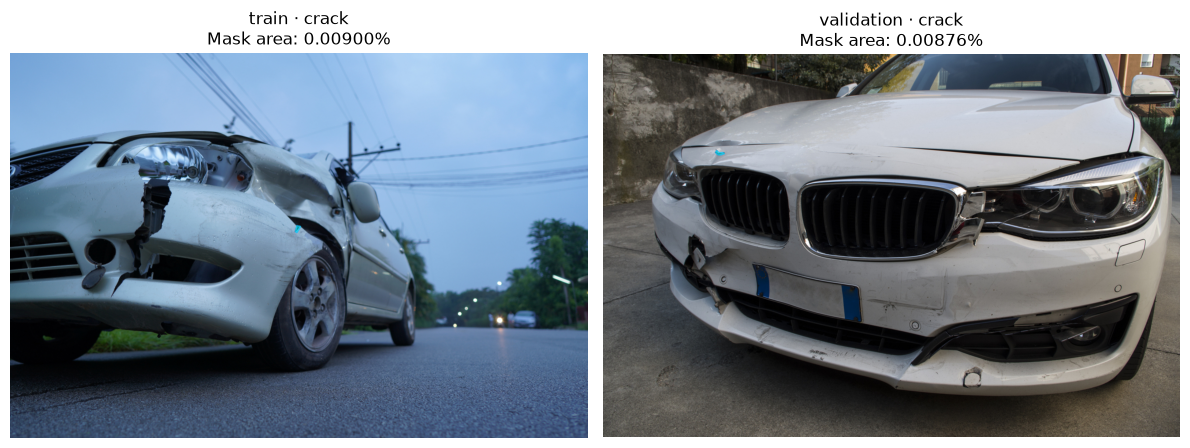

In [34]:
figure, axes = plt.subplots(1, len(cardd_small_masks), figsize=(6 * len(cardd_small_masks), 6))

if len(cardd_small_masks) == 1:
    axes = [axes]

for axis, row in zip(axes, cardd_small_masks.itertuples(index=False)):
    plot_coco_annotation("CarDD", row.split, row.annotation_id, axis)

plt.tight_layout()
plt.show()

## CarDD review decision

Both reviewed crack masks are too small and poorly represent the visible damage. They are treated as annotation noise and excluded explicitly by annotation ID.

Before applying the removal, all annotations belonging to the two affected images are checked. An image must also be excluded if removing the selected mask leaves it without any valid annotations.

### Inspect affected images

In [35]:
cardd_review_image_records = []

for row in cardd_small_masks.itertuples(index=False):
    coco = prepared_coco[("CarDD", row.split)]
    categories_by_id = {category["id"]: category["name"] for category in coco["categories"]}

    for annotation in coco["annotations"]:
        if annotation["image_id"] != row.image_id:
            continue

        cardd_review_image_records.append({
            "split": row.split,
            "image_id": row.image_id,
            "file_name": row.file_name,
            "annotation_id": annotation["id"],
            "category": categories_by_id[annotation["category_id"]],
            "area": annotation["area"],
        })

cardd_review_image_annotations = pd.DataFrame(cardd_review_image_records)
cardd_review_image_annotations

,split,image_id,file_name,annotation_id,category,area
0,train,1490,001490.jpg,2226,dent,10611.0
1,train,1490,001490.jpg,2227,scratch,19204.0
2,train,1490,001490.jpg,2228,crack,5893.0
3,train,1490,001490.jpg,2229,crack,60.0
4,train,1490,001490.jpg,2230,lamp broken,16077.0
5,validation,3475,003475.jpg,1554,scratch,4129.0
6,validation,3475,003475.jpg,1555,crack,277.0
7,validation,3475,003475.jpg,1556,crack,58.0
8,validation,3475,003475.jpg,1557,lamp broken,34005.0


## Apply CarDD annotation cleanup

Remove the two manually confirmed unusable crack masks. Their source images remain because they contain other valid damage annotations.

### Define removals

In [36]:
cardd_annotation_removals = {
    "train": {2229},
    "validation": {1556},
    "test": set(),
}

### Remove annotations

In [37]:
cardd_cleanup_records = []

for split, removal_ids in cardd_annotation_removals.items():
    coco = prepared_coco[("CarDD", split)]
    annotations_before = len(coco["annotations"])

    coco["annotations"] = [
        annotation for annotation in coco["annotations"]
        if annotation["id"] not in removal_ids
    ]

    cardd_cleanup_records.append({
        "split": split,
        "images": len(coco["images"]),
        "annotations_before": annotations_before,
        "annotations_removed": annotations_before - len(coco["annotations"]),
        "annotations_after": len(coco["annotations"]),
    })

cardd_cleanup_report = pd.DataFrame(cardd_cleanup_records)
cardd_cleanup_report

,split,images,annotations_before,annotations_removed,annotations_after
0,train,2816,6211,1,6210
1,validation,810,1744,1,1743
2,test,374,785,0,785


## Verify CarDD cleanup

Confirm that the selected annotations are absent and that every remaining annotation references an existing image and category.

### Validate CarDD references

In [38]:
for split, removal_ids in cardd_annotation_removals.items():
    coco = prepared_coco[("CarDD", split)]
    annotation_ids = {annotation["id"] for annotation in coco["annotations"]}
    image_ids = {image["id"] for image in coco["images"]}
    category_ids = {category["id"] for category in coco["categories"]}

    assert annotation_ids.isdisjoint(removal_ids)
    assert all(annotation["image_id"] in image_ids for annotation in coco["annotations"])
    assert all(annotation["category_id"] in category_ids for annotation in coco["annotations"])

print("CarDD cleanup passed all reference checks.")

CarDD cleanup passed all reference checks.


## Severity bounding-box repair

The audit found 117 Severity bounding boxes extending slightly beyond image boundaries. The maximum overflow was 0.5 pixels, indicating an export rounding issue rather than incorrect damage localization.

Bounding boxes are clipped to their recorded image dimensions. Segmentation polygons and mask areas remain unchanged.

### Bounding-box clipping utility

In [39]:
def clip_bbox(bbox, image_width, image_height):
    x, y, width, height = map(float, bbox)

    left = min(max(x, 0.0), image_width)
    top = min(max(y, 0.0), image_height)
    right = min(max(x + width, left), image_width)
    bottom = min(max(y + height, top), image_height)

    return [left, top, right - left, bottom - top]

### Repair Severity boxes

In [40]:
severity_bbox_repairs = []

for split in ["train", "validation", "test"]:
    coco = prepared_coco[("Severity", split)]
    images_by_id = {image["id"]: image for image in coco["images"]}
    repaired_count = 0

    for annotation in coco["annotations"]:
        image = images_by_id[annotation["image_id"]]
        original_bbox = annotation["bbox"]
        clipped_bbox = clip_bbox(original_bbox, image["width"], image["height"])

        if any(abs(before - after) > 1e-9 for before, after in zip(original_bbox, clipped_bbox)):
            annotation["bbox"] = clipped_bbox
            repaired_count += 1

    severity_bbox_repairs.append({
        "split": split,
        "bounding_boxes_repaired": repaired_count,
    })

severity_bbox_repair_report = pd.DataFrame(severity_bbox_repairs)
severity_bbox_repair_report

,split,bounding_boxes_repaired
0,train,80
1,validation,22
2,test,15


## Verify repaired Severity boxes

Every repaired bounding box must have positive dimensions and remain fully inside its recorded image.

### Validate bounding boxes

In [41]:
severity_bbox_errors = []

for split in ["train", "validation", "test"]:
    coco = prepared_coco[("Severity", split)]
    images_by_id = {image["id"]: image for image in coco["images"]}

    for annotation in coco["annotations"]:
        image = images_by_id[annotation["image_id"]]
        x, y, width, height = annotation["bbox"]

        if width <= 0 or height <= 0:
            severity_bbox_errors.append((split, annotation["id"], "invalid dimensions"))
        elif x < 0 or y < 0 or x + width > image["width"] or y + height > image["height"]:
            severity_bbox_errors.append((split, annotation["id"], "outside image"))

print(f"Invalid Severity bounding boxes after repair: {len(severity_bbox_errors)}")
assert not severity_bbox_errors

Invalid Severity bounding boxes after repair: 0


## Severity small-mask filtering policy

Severity annotations covering less than 0.01% of an image are too small to provide a stable segmentation or severity-training signal at the dataset's resolution.

These masks are excluded from the processed dataset. The threshold and removal counts are retained in the preparation report as a known dataset-quality decision.

### Collect small masks


In [42]:
severity_small_mask_records = []

for split in ["train", "validation", "test"]:
    coco = prepared_coco[("Severity", split)]
    images_by_id = {image["id"]: image for image in coco["images"]}
    categories_by_id = {category["id"]: category["name"] for category in coco["categories"]}

    for annotation in coco["annotations"]:
        image = images_by_id[annotation["image_id"]]
        relative_area_pct = 100 * annotation["area"] / (image["width"] * image["height"])

        if relative_area_pct < VERY_SMALL_MASK_PCT:
            severity_small_mask_records.append({
                "split": split,
                "annotation_id": annotation["id"],
                "image_id": annotation["image_id"],
                "category_id": annotation["category_id"],
                "category": categories_by_id[annotation["category_id"]],
                "relative_area_pct": relative_area_pct,
            })

severity_small_masks = pd.DataFrame(severity_small_mask_records)

print(f"Severity masks selected for removal: {len(severity_small_masks):,}")

Severity masks selected for removal: 592


### Removal counts by category

In [43]:
severity_small_mask_category_summary = (
    severity_small_masks.groupby(["category_id", "category"])
    .size()
    .rename("annotations_to_remove")
    .reset_index()
    .sort_values("annotations_to_remove", ascending=False)
)

severity_small_mask_category_summary

,category_id,category,annotations_to_remove
1,2,minor-scratch,578
0,1,minor-dent,8
3,4,moderate-dent,3
4,5,moderate-scratch,2
2,3,moderate-broken,1


## Measure filtering impact

Check how many images are affected and identify images that would lose all annotations. Those images will also be excluded because they cannot be treated as verified background examples.

### Calculate image impact

In [44]:
from collections import Counter

severity_small_mask_impact = []

for split in ["train", "validation", "test"]:
    coco = prepared_coco[("Severity", split)]
    annotations_per_image = Counter(
        annotation["image_id"] for annotation in coco["annotations"]
    )

    split_removals = severity_small_masks.query("split == @split")
    removals_per_image = Counter(split_removals["image_id"])
    affected_image_ids = set(removals_per_image)

    images_losing_all = {
        image_id
        for image_id in affected_image_ids
        if removals_per_image[image_id] == annotations_per_image[image_id]
    }

    severity_small_mask_impact.append({
        "split": split,
        "annotations_to_remove": len(split_removals),
        "affected_images": len(affected_image_ids),
        "images_losing_all_annotations": len(images_losing_all),
    })

severity_small_mask_impact = pd.DataFrame(severity_small_mask_impact)
severity_small_mask_impact

,split,annotations_to_remove,affected_images,images_losing_all_annotations
0,train,440,317,44
1,validation,92,72,12
2,test,60,41,7


## Apply Severity small-mask cleanup

Remove the 592 unusably small masks. Images without any remaining annotations are also excluded because the severity model operates on confirmed damage regions, and these images cannot be trusted as verified negative examples.

Raw images and annotations remain unchanged.

### Prepare removal IDs

In [45]:
severity_annotation_removals = {
    split: set(
        severity_small_masks.loc[
            severity_small_masks["split"].eq(split),
            "annotation_id",
        ]
    )
    for split in ["train", "validation", "test"]
}

### Remove masks and unannotated images

In [46]:
severity_mask_cleanup_records = []

for split, removal_ids in severity_annotation_removals.items():
    coco = prepared_coco[("Severity", split)]

    all_image_ids = {image["id"] for image in coco["images"]}
    annotated_before = {annotation["image_id"] for annotation in coco["annotations"]}
    preexisting_unannotated = all_image_ids - annotated_before

    annotations_before = len(coco["annotations"])
    coco["annotations"] = [
        annotation for annotation in coco["annotations"]
        if annotation["id"] not in removal_ids
    ]

    annotated_after = {annotation["image_id"] for annotation in coco["annotations"]}
    newly_unannotated = annotated_before - annotated_after
    removed_image_ids = all_image_ids - annotated_after

    coco["images"] = [
        image for image in coco["images"]
        if image["id"] not in removed_image_ids
    ]

    severity_mask_cleanup_records.append({
        "split": split,
        "annotations_removed": annotations_before - len(coco["annotations"]),
        "preexisting_unannotated_images": len(preexisting_unannotated),
        "newly_unannotated_images": len(newly_unannotated),
        "images_removed": len(removed_image_ids),
        "images_after": len(coco["images"]),
        "annotations_after": len(coco["annotations"]),
    })

severity_mask_cleanup_report = pd.DataFrame(severity_mask_cleanup_records)
severity_mask_cleanup_report

,split,annotations_removed,preexisting_unannotated_images,newly_unannotated_images,images_removed,images_after,annotations_after
0,train,440,92,44,136,3504,7250
1,validation,92,28,12,40,984,2024
2,test,60,14,7,21,613,1332


## Verify Severity mask cleanup

Confirm that all retained images contain annotations, all references are valid, and no mask remains below the selected threshold.

### Validate retained records

In [47]:
remaining_small_masks = 0

for split in ["train", "validation", "test"]:
    coco = prepared_coco[("Severity", split)]
    images_by_id = {image["id"]: image for image in coco["images"]}
    category_ids = {category["id"] for category in coco["categories"]}
    referenced_image_ids = {annotation["image_id"] for annotation in coco["annotations"]}

    assert referenced_image_ids == set(images_by_id)
    assert all(annotation["category_id"] in category_ids for annotation in coco["annotations"])

    for annotation in coco["annotations"]:
        image = images_by_id[annotation["image_id"]]
        relative_area_pct = 100 * annotation["area"] / (image["width"] * image["height"])
        remaining_small_masks += relative_area_pct < VERY_SMALL_MASK_PCT

print(f"Severity masks below {VERY_SMALL_MASK_PCT}% after cleanup: {remaining_small_masks}")
assert remaining_small_masks == 0

Severity masks below 0.01% after cleanup: 0


## Severity source and duplicate inventory

Roboflow filenames contain a source-image name followed by an `.rf.<hash>` suffix. Augmented exports from the same original image must remain in the same split.

Each retained image is assigned:

- its original split and image ID;
- its inferred source name;
- a SHA-256 pixel-file hash;
- its annotation count and category signature.

### Source-name parser

In [48]:
import re

RF_SUFFIX = re.compile(r"\.rf\.[0-9a-f]+$", re.IGNORECASE)


def extract_source_name(file_name):
    return RF_SUFFIX.sub("", Path(file_name).stem).lower()

### Build Severity inventory

In [49]:
severity_image_records = []

for row in split_paths.query("dataset == 'Severity'").itertuples(index=False):
    coco = prepared_coco[("Severity", row.split)]
    annotations_by_image = {}

    for annotation in coco["annotations"]:
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    print(f"Hashing Severity {row.split}: {len(coco['images'])} images")

    for image in coco["images"]:
        annotations = annotations_by_image[image["id"]]
        image_path = row.image_directory / image["file_name"]

        severity_image_records.append({
            "record_key": f"{row.split}:{image['id']}",
            "original_split": row.split,
            "original_image_id": image["id"],
            "file_name": image["file_name"],
            "image_path": image_path,
            "source_name": extract_source_name(image["file_name"]),
            "sha256": sha256_file(image_path),
            "annotation_count": len(annotations),
            "category_signature": tuple(sorted(
                annotation["category_id"] for annotation in annotations
            )),
            "annotation_signature": annotation_signature(annotations),
        })

severity_images = pd.DataFrame(severity_image_records)
print(f"Retained Severity images: {len(severity_images):,}")

Hashing Severity train: 3504 images
Hashing Severity validation: 984 images
Hashing Severity test: 613 images
Retained Severity images: 5,101


## Source overlap after filtering

Measure how many inferred source images still appear in multiple original splits. These overlaps will be resolved by rebuilding the splits at source-group level.

In [50]:
severity_source_summary = (
    severity_images.groupby("original_split")
    .agg(
        retained_images=("record_key", "size"),
        estimated_sources=("source_name", "nunique"),
    )
    .reset_index()
)

severity_source_summary

,original_split,retained_images,estimated_sources
0,test,613,611
1,train,3504,3272
2,validation,984,959


### Cross-split source overlap

In [51]:
severity_source_groups = (
    severity_images.groupby("source_name")
    .agg(
        exported_images=("record_key", "size"),
        split_count=("original_split", "nunique"),
        splits=("original_split", lambda values: ", ".join(sorted(set(values)))),
    )
    .reset_index()
)

severity_cross_split_sources = severity_source_groups[
    severity_source_groups["split_count"].gt(1)
].copy()

print(f"Sources appearing in multiple original splits: {len(severity_cross_split_sources):,}")
print(f"Affected retained images: {severity_cross_split_sources['exported_images'].sum():,}")

Sources appearing in multiple original splits: 205
Affected retained images: 443


## Exact duplicate groups after filtering

Exact pixel duplicates require a separate decision because some copies contain different annotation counts or geometries.

#### Duplicate summary

In [52]:
severity_hash_groups = (
    severity_images.groupby("sha256")
    .agg(
        files=("record_key", "size"),
        split_count=("original_split", "nunique"),
        source_count=("source_name", "nunique"),
        annotation_count_variants=("annotation_count", "nunique"),
        category_variants=("category_signature", "nunique"),
        annotation_variants=("annotation_signature", "nunique"),
    )
    .reset_index()
)

severity_duplicate_groups = severity_hash_groups[
    severity_hash_groups["files"].gt(1)
].copy()

severity_duplicate_groups

,sha256,files,split_count,source_count,annotation_count_variants,category_variants,annotation_variants
1783,5aa9e1fe80f6e9b7492e039207ff7cd4ee35b4cd8f20d8...,2,2,2,1,1,2
2625,85b18306c55047528671b8da6bb5eb6ef21eba27c169d6...,2,2,2,2,2,2
2646,86ae3d6016cbea1f2b66405aa444edf10f16f10f5591a3...,2,1,2,2,2,2
3444,adfea8095a7fb4ad9ad014b1899d57b662df3d9e59a352...,2,2,2,1,1,2
3680,baa8db3cbf8d25650eda15f72833fed3727132791036d6...,2,2,2,1,1,2
4799,f210680d42d479535cc01a0d9f6bb557d4b02dd165e962...,2,1,2,2,2,2


### Duplicate image details

In [53]:
duplicate_hashes = set(severity_duplicate_groups["sha256"])

severity_duplicate_details = (
    severity_images[severity_images["sha256"].isin(duplicate_hashes)]
    .sort_values(["sha256", "original_split", "file_name"])
)

severity_duplicate_details[[
    "sha256",
    "original_split",
    "file_name",
    "source_name",
    "annotation_count",
    "category_signature",
]]

,sha256,original_split,file_name,source_name,annotation_count,category_signature
250,5aa9e1fe80f6e9b7492e039207ff7cd4ee35b4cd8f20d8...,train,9513150-hyundai-hyundai_elite_i20_2014-2018_sp...,9513150-hyundai-hyundai_elite_i20_2014-2018_sp...,2,"(1, 4)"
3516,5aa9e1fe80f6e9b7492e039207ff7cd4ee35b4cd8f20d8...,validation,9513150-hyundai-hyundai_elite_i20_2014-2018_sp...,9513150-hyundai-hyundai_elite_i20_2014-2018_sp...,2,"(1, 4)"
4666,85b18306c55047528671b8da6bb5eb6ef21eba27c169d6...,test,8340581-nissan-nissan_sunny_2014-2020_xv-2017-...,8340581-nissan-nissan_sunny_2014-2020_xv-2017-...,1,"(2,)"
455,85b18306c55047528671b8da6bb5eb6ef21eba27c169d6...,train,8340581-nissan-nissan_sunny_2014-2020_xv-2017-...,8340581-nissan-nissan_sunny_2014-2020_xv-2017-...,2,"(2, 2)"
672,86ae3d6016cbea1f2b66405aa444edf10f16f10f5591a3...,train,9950420-hyundai-hyundai_venue_2019-2022_sx_10_...,9950420-hyundai-hyundai_venue_2019-2022_sx_10_...,3,"(2, 2, 2)"
3216,86ae3d6016cbea1f2b66405aa444edf10f16f10f5591a3...,train,9950420-hyundai-hyundai_venue_2019-2022_sx_10_...,9950420-hyundai-hyundai_venue_2019-2022_sx_10_...,4,"(2, 2, 2, 2)"
1532,adfea8095a7fb4ad9ad014b1899d57b662df3d9e59a352...,train,8210429-skoda-skoda_kushaq_ambition_10l_tsi_mt...,8210429-skoda-skoda_kushaq_ambition_10l_tsi_mt...,1,"(2,)"
4295,adfea8095a7fb4ad9ad014b1899d57b662df3d9e59a352...,validation,8210429-skoda-skoda_kushaq_ambition_10l_tsi_mt...,8210429-skoda-skoda_kushaq_ambition_10l_tsi_mt...,1,"(2,)"
362,baa8db3cbf8d25650eda15f72833fed3727132791036d6...,train,8591497-hyundai-hyundai_grand_i10_2017-2020_sp...,8591497-hyundai-hyundai_grand_i10_2017-2020_sp...,1,"(5,)"
4412,baa8db3cbf8d25650eda15f72833fed3727132791036d6...,validation,8591497-hyundai-hyundai_grand_i10_2017-2020_sp...,8591497-hyundai-hyundai_grand_i10_2017-2020_sp...,1,"(5,)"


## Resolve Severity exact duplicates

Exact duplicate images with conflicting annotations cannot all remain. For each pixel-identical group, retain the most complete annotation version using annotation count, polygon detail, and total mask area.

The raw exports remain unchanged, and the selected and removed records are recorded for reporting.

### Annotation lookup

In [54]:
severity_annotation_lookup = {}

for split in ["train", "validation", "test"]:
    for annotation in prepared_coco[("Severity", split)]["annotations"]:
        key = (split, annotation["image_id"])
        severity_annotation_lookup.setdefault(key, []).append(annotation)

### Geometry-detail utility

In [55]:
def polygon_vertex_count(segmentation):
    if not isinstance(segmentation, list):
        return 0

    return sum(
        len(polygon) // 2
        for polygon in segmentation
        if isinstance(polygon, list)
    )

### Score duplicate candidates

In [56]:
severity_duplicate_candidates = severity_images[
    severity_images["sha256"].isin(duplicate_hashes)
].copy()

severity_duplicate_candidates["polygon_vertices"] = [
    sum(
        polygon_vertex_count(annotation["segmentation"])
        for annotation in severity_annotation_lookup[
            (row.original_split, row.original_image_id)
        ]
    )
    for row in severity_duplicate_candidates.itertuples(index=False)
]

severity_duplicate_candidates["total_mask_area"] = [
    sum(
        annotation["area"]
        for annotation in severity_annotation_lookup[
            (row.original_split, row.original_image_id)
        ]
    )
    for row in severity_duplicate_candidates.itertuples(index=False)
]

### Select retained versions

In [57]:
severity_duplicate_candidates = severity_duplicate_candidates.sort_values(
    [
        "sha256",
        "annotation_count",
        "polygon_vertices",
        "total_mask_area",
        "record_key",
    ],
    ascending=[True, False, False, False, True],
)

selected_duplicate_records = (
    severity_duplicate_candidates.groupby("sha256", as_index=False)
    .head(1)
)

selected_record_keys = set(selected_duplicate_records["record_key"])

severity_duplicate_candidates["decision"] = severity_duplicate_candidates[
    "record_key"
].map(lambda key: "retain" if key in selected_record_keys else "remove")

severity_duplicate_candidates[[
    "sha256",
    "original_split",
    "file_name",
    "annotation_count",
    "polygon_vertices",
    "total_mask_area",
    "decision",
]]

,sha256,original_split,file_name,annotation_count,polygon_vertices,total_mask_area,decision
3516,5aa9e1fe80f6e9b7492e039207ff7cd4ee35b4cd8f20d8...,validation,9513150-hyundai-hyundai_elite_i20_2014-2018_sp...,2,115,8839.114,retain
250,5aa9e1fe80f6e9b7492e039207ff7cd4ee35b4cd8f20d8...,train,9513150-hyundai-hyundai_elite_i20_2014-2018_sp...,2,24,9152.778,remove
455,85b18306c55047528671b8da6bb5eb6ef21eba27c169d6...,train,8340581-nissan-nissan_sunny_2014-2020_xv-2017-...,2,30,857.115,retain
4666,85b18306c55047528671b8da6bb5eb6ef21eba27c169d6...,test,8340581-nissan-nissan_sunny_2014-2020_xv-2017-...,1,5,500.000,remove
3216,86ae3d6016cbea1f2b66405aa444edf10f16f10f5591a3...,train,9950420-hyundai-hyundai_venue_2019-2022_sx_10_...,4,33,4802.778,retain
672,86ae3d6016cbea1f2b66405aa444edf10f16f10f5591a3...,train,9950420-hyundai-hyundai_venue_2019-2022_sx_10_...,3,51,2000.057,remove
4295,adfea8095a7fb4ad9ad014b1899d57b662df3d9e59a352...,validation,8210429-skoda-skoda_kushaq_ambition_10l_tsi_mt...,1,11,101.343,retain
1532,adfea8095a7fb4ad9ad014b1899d57b662df3d9e59a352...,train,8210429-skoda-skoda_kushaq_ambition_10l_tsi_mt...,1,7,908.333,remove
4412,baa8db3cbf8d25650eda15f72833fed3727132791036d6...,validation,8591497-hyundai-hyundai_grand_i10_2017-2020_sp...,1,107,48425.000,retain
362,baa8db3cbf8d25650eda15f72833fed3727132791036d6...,train,8591497-hyundai-hyundai_grand_i10_2017-2020_sp...,1,81,32592.036,remove


## Apply Severity deduplication

Remove the unselected image records and their annotations from the preparation copies.

### Build removal sets

In [58]:
severity_duplicate_removals = severity_duplicate_candidates[
    severity_duplicate_candidates["decision"].eq("remove")
].copy()

severity_duplicate_removal_ids = {
    split: set(
        severity_duplicate_removals.loc[
            severity_duplicate_removals["original_split"].eq(split),
            "original_image_id",
        ]
    )
    for split in ["train", "validation", "test"]
}

### Remove duplicate records

In [59]:
severity_dedup_records = []

for split, removal_ids in severity_duplicate_removal_ids.items():
    coco = prepared_coco[("Severity", split)]
    images_before = len(coco["images"])
    annotations_before = len(coco["annotations"])

    coco["images"] = [
        image for image in coco["images"]
        if image["id"] not in removal_ids
    ]
    coco["annotations"] = [
        annotation for annotation in coco["annotations"]
        if annotation["image_id"] not in removal_ids
    ]

    severity_dedup_records.append({
        "split": split,
        "images_removed": images_before - len(coco["images"]),
        "annotations_removed": annotations_before - len(coco["annotations"]),
    })

severity_dedup_report = pd.DataFrame(severity_dedup_records)
severity_dedup_report

,split,images_removed,annotations_removed
0,train,5,9
1,validation,0,0
2,test,1,1


### Update retained inventory

In [60]:
removed_record_keys = set(severity_duplicate_removals["record_key"])
severity_images_before_dedup = severity_images.copy()

severity_images = severity_images[
    ~severity_images["record_key"].isin(removed_record_keys)
].copy()

print(f"Severity images after exact deduplication: {len(severity_images):,}")

Severity images after exact deduplication: 5,095


## Verify Severity deduplication

Confirm that every exact pixel hash now occurs only once.

In [61]:
remaining_exact_duplicates = severity_images["sha256"].duplicated().sum()

print(f"Remaining exact duplicate files: {remaining_exact_duplicates}")
assert remaining_exact_duplicates == 0

Remaining exact duplicate files: 0


## Severity split policy

The Severity dataset is rebuilt using source-grouped assignment:

- Training: 70%
- Validation: 15%
- Test: 15%
- Random seed: 42
- All exports from one inferred source remain together.
- Image counts and all eight annotation classes contribute to split balancing.

The assignment is deterministic and does not use the original leaked split labels.

### Split parameters

In [62]:
SEVERITY_SPLIT_RATIOS = {
    "train": 0.70,
    "validation": 0.15,
    "test": 0.15,
}

RANDOM_SEED = 42

assert abs(sum(SEVERITY_SPLIT_RATIOS.values()) - 1.0) < 1e-9

## Build source-group statistics

Count retained images and severity-class annotations for every inferred source group.

In [63]:
severity_category_names = {
    category["id"]: category["name"]
    for category in prepared_coco[("Severity", "train")]["categories"]
}

severity_category_columns = {
    category_id: f"category_{category_id}"
    for category_id in severity_category_names
}

### Add image-level category counts

In [64]:
for category_id, column in severity_category_columns.items():
    severity_images[column] = [
        sum(
            annotation["category_id"] == category_id
            for annotation in severity_annotation_lookup[
                (row.original_split, row.original_image_id)
            ]
        )
        for row in severity_images.itertuples(index=False)
    ]

### Aggregate source groups

In [65]:
source_aggregations = {
    "exported_images": ("record_key", "size"),
}

source_aggregations.update({
    column: (column, "sum")
    for column in severity_category_columns.values()
})

severity_source_stats = (
    severity_images.groupby("source_name")
    .agg(**source_aggregations)
    .reset_index()
)

print(f"Source groups available for splitting: {len(severity_source_stats):,}")

Source groups available for splitting: 4,628


## Assign source groups

Rare-class-heavy source groups are assigned first. Each group is placed into the split that best reduces the combined image-count and class-distribution error.

#### Group assignment function

In [66]:
def assign_source_groups(group_stats, split_ratios, category_columns, seed):
    split_names = list(split_ratios)
    metric_columns = ["exported_images", *category_columns]
    totals = group_stats[metric_columns].sum().astype(float)

    targets = pd.DataFrame({
        split: totals * ratio
        for split, ratio in split_ratios.items()
    }).T

    current = pd.DataFrame(
        0.0,
        index=split_names,
        columns=metric_columns,
    )

    ordered = group_stats.copy()
    ordered["priority"] = sum(
        ordered[column] / totals[column]
        for column in category_columns
    )
    ordered["priority"] += ordered["exported_images"] / totals["exported_images"]

    rng = np.random.default_rng(seed)
    ordered["tie_breaker"] = rng.random(len(ordered))
    ordered = ordered.sort_values(
        ["priority", "tie_breaker"],
        ascending=[False, True],
    )

    assignments = []

    for _, group in ordered.iterrows():
        values = group[metric_columns].astype(float)
        split_costs = {}

        for split in split_names:
            candidate = current.copy()
            candidate.loc[split] += values

            relative_error = (candidate - targets) / targets
            image_cost = relative_error["exported_images"].pow(2).mean()
            class_cost = relative_error[category_columns].pow(2).mean().mean()

            overflow = ((candidate - targets).clip(lower=0) / targets).pow(2)
            overflow_cost = overflow.mean().mean()

            split_costs[split] = 2 * image_cost + class_cost + overflow_cost

        selected_split = min(split_costs, key=split_costs.get)
        current.loc[selected_split] += values
        assignments.append({
            "source_name": group["source_name"],
            "assigned_split": selected_split,
        })

    return pd.DataFrame(assignments), targets, current

In [67]:
category_columns = list(severity_category_columns.values())

severity_source_assignment, severity_split_targets, severity_split_actual = (
    assign_source_groups(
        severity_source_stats,
        SEVERITY_SPLIT_RATIOS,
        category_columns,
        RANDOM_SEED,
    )
)

severity_images = severity_images.merge(
    severity_source_assignment,
    on="source_name",
    how="left",
    validate="many_to_one",
)

assert severity_images["assigned_split"].notna().all()

## Review rebuilt split sizes

Compare the resulting image and annotation distributions against the requested split ratios.

### Image and annotation summary

In [68]:
severity_rebuilt_summary = (
    severity_images.groupby("assigned_split")
    .agg(
        images=("record_key", "size"),
        annotations=("annotation_count", "sum"),
        source_groups=("source_name", "nunique"),
    )
    .reindex(["train", "validation", "test"])
    .reset_index()
)

severity_rebuilt_summary["image_share_pct"] = (
    100 * severity_rebuilt_summary["images"] / severity_rebuilt_summary["images"].sum()
).round(2)

severity_rebuilt_summary["annotation_share_pct"] = (
    100 * severity_rebuilt_summary["annotations"]
    / severity_rebuilt_summary["annotations"].sum()
).round(2)

severity_rebuilt_summary

,assigned_split,images,annotations,source_groups,image_share_pct,annotation_share_pct
0,train,3612,6247,3565,70.89,58.96
1,validation,741,2174,531,14.54,20.52
2,test,742,2175,532,14.56,20.53


##### Class distribution

In [69]:
severity_class_distribution = (
    severity_images.groupby("assigned_split")[category_columns]
    .sum()
    .reindex(["train", "validation", "test"])
    .T
)

severity_class_distribution["category"] = [
    severity_category_names[category_id]
    for category_id in severity_category_columns
]

severity_class_distribution = severity_class_distribution.set_index("category")
severity_class_distribution

assigned_split,train,validation,test
category,,,
minor-dent,221,71,71
minor-scratch,4100,1410,1410
moderate-broken,362,120,120
moderate-dent,518,192,193
moderate-scratch,484,204,203
severe-broken,275,83,83
severe-dent,204,70,71
severe-scratch,83,24,24


##### Confirm source isolation

In [70]:
source_split_counts = severity_images.groupby("source_name")["assigned_split"].nunique()
leaking_source_groups = source_split_counts[source_split_counts.gt(1)]

print(f"Source groups appearing in multiple rebuilt splits: {len(leaking_source_groups)}")
assert leaking_source_groups.empty

Source groups appearing in multiple rebuilt splits: 0


## Search for a balanced grouped split

Source groups are repeatedly shuffled and assigned while respecting the target image capacity. The candidate with the lowest combined image and per-class distribution error is retained.

This avoids source leakage while preventing annotation-heavy sources from accumulating in the evaluation splits.

### Capacity-based assignment

In [71]:
def assign_by_image_capacity(group_sizes, target_ratios, rng):
    targets = group_sizes.sum() * target_ratios
    current = np.zeros(len(target_ratios))
    assignments = np.full(len(group_sizes), -1, dtype=int)

    for group_index in rng.permutation(len(group_sizes)):
        relative_remaining = (targets - current) / targets
        best_splits = np.flatnonzero(
            np.isclose(relative_remaining, relative_remaining.max())
        )
        selected_split = rng.choice(best_splits)

        assignments[group_index] = selected_split
        current[selected_split] += group_sizes[group_index]

    return assignments


##### Candidate scoring

In [72]:
def grouped_split_score(assignments, metric_values, target_ratios):
    actual = np.vstack([
        metric_values[assignments == split_index].sum(axis=0)
        for split_index in range(len(target_ratios))
    ])

    observed_shares = actual / metric_values.sum(axis=0)
    relative_error = (
        observed_shares - target_ratios[:, None]
    ) / target_ratios[:, None]

    image_error = np.mean(relative_error[:, 0] ** 2)
    class_error = np.mean(relative_error[:, 1:] ** 2)
    worst_class_error = np.max(np.abs(relative_error[:, 1:]))

    return 2 * image_error + class_error + 0.1 * worst_class_error**2

##### Repeated search

In [73]:
def search_grouped_split(group_stats, split_ratios, category_columns, seed, trials=1000):
    split_names = list(split_ratios)
    target_ratios = np.asarray(list(split_ratios.values()))
    metric_columns = ["exported_images", *category_columns]
    metric_values = group_stats[metric_columns].to_numpy(dtype=float)
    group_sizes = metric_values[:, 0]

    rng = np.random.default_rng(seed)
    best_assignments = None
    best_score = np.inf

    for _ in range(trials):
        assignments = assign_by_image_capacity(group_sizes, target_ratios, rng)
        score = grouped_split_score(assignments, metric_values, target_ratios)

        if score < best_score:
            best_score = score
            best_assignments = assignments.copy()

    result = group_stats[["source_name"]].copy()
    result["assigned_split"] = [
        split_names[index] for index in best_assignments
    ]

    return result, best_score

### Rebuild assignment

In [74]:
severity_source_assignment, severity_assignment_score = search_grouped_split(
    severity_source_stats,
    SEVERITY_SPLIT_RATIOS,
    category_columns,
    RANDOM_SEED,
    trials=1000,
)

severity_images = severity_images.drop(
    columns="assigned_split",
    errors="ignore",
).merge(
    severity_source_assignment,
    on="source_name",
    how="left",
    validate="many_to_one",
)

print(f"Selected grouped-split score: {severity_assignment_score:.6f}")

Selected grouped-split score: 0.005124


#### Recalculate summary

In [75]:
severity_rebuilt_summary = (
    severity_images.groupby("assigned_split")
    .agg(
        images=("record_key", "size"),
        annotations=("annotation_count", "sum"),
        source_groups=("source_name", "nunique"),
    )
    .reindex(["train", "validation", "test"])
    .reset_index()
)

severity_rebuilt_summary["image_share_pct"] = (
    100 * severity_rebuilt_summary["images"] / severity_rebuilt_summary["images"].sum()
).round(2)

severity_rebuilt_summary["annotation_share_pct"] = (
    100 * severity_rebuilt_summary["annotations"]
    / severity_rebuilt_summary["annotations"].sum()
).round(2)

severity_rebuilt_summary

,assigned_split,images,annotations,source_groups,image_share_pct,annotation_share_pct
0,train,3566,7446,3241,69.99,70.27
1,validation,764,1563,698,15.00,14.75
2,test,765,1587,689,15.01,14.98


#### Recalculate class distribution

In [76]:
severity_class_distribution = (
    severity_images.groupby("assigned_split")[category_columns]
    .sum()
    .reindex(["train", "validation", "test"])
    .T
)

severity_class_distribution["category"] = [
    severity_category_names[category_id]
    for category_id in severity_category_columns
]

severity_class_distribution = severity_class_distribution.set_index("category")
severity_class_distribution

assigned_split,train,validation,test
category,,,
minor-dent,248,55,60
minor-scratch,4888,1012,1020
moderate-broken,421,87,94
moderate-dent,612,143,148
moderate-scratch,640,117,134
severe-broken,309,71,61
severe-dent,240,56,49
severe-scratch,88,22,21


#### Class-share check

In [77]:
severity_class_shares = (
    100 * severity_class_distribution
    / severity_class_distribution.sum(axis=1).to_numpy()[:, None]
).round(2)

severity_class_shares

assigned_split,train,validation,test
category,,,
minor-dent,68.32,15.15,16.53
minor-scratch,70.64,14.62,14.74
moderate-broken,69.93,14.45,15.61
moderate-dent,67.77,15.84,16.39
moderate-scratch,71.83,13.13,15.04
severe-broken,70.07,16.10,13.83
severe-dent,69.57,16.23,14.20
severe-scratch,67.18,16.79,16.03


## Rebuild Severity COCO splits

The original split-local image and annotation IDs may overlap. New sequential IDs are assigned within each rebuilt split.

Category IDs remain unchanged. A manifest preserves the connection between each processed image and its original file.

### Check filename uniqueness

In [78]:
duplicate_file_names = severity_images[
    severity_images["file_name"].duplicated(keep=False)
]

print(f"Duplicate retained filenames: {len(duplicate_file_names)}")
assert duplicate_file_names.empty

Duplicate retained filenames: 0


#### Original image lookup

In [79]:
severity_image_lookup = {}

for split in ["train", "validation", "test"]:
    for image in prepared_coco[("Severity", split)]["images"]:
        severity_image_lookup[(split, image["id"])] = image

#### COCO rebuilding utility

In [80]:
def build_reassigned_coco(image_rows, image_lookup, annotation_lookup, base_coco):
    images = []
    annotations = []
    manifest = []
    annotation_id = 1

    ordered_rows = image_rows.sort_values(
        ["source_name", "file_name", "record_key"]
    )

    for new_image_id, row in enumerate(ordered_rows.itertuples(index=False), start=1):
        source_key = (row.original_split, row.original_image_id)
        image = deepcopy(image_lookup[source_key])
        image["id"] = new_image_id
        images.append(image)

        manifest.append({
            "new_image_id": new_image_id,
            "file_name": row.file_name,
            "source_name": row.source_name,
            "source_path": row.image_path,
            "original_split": row.original_split,
            "original_image_id": row.original_image_id,
            "sha256": row.sha256,
        })

        for source_annotation in annotation_lookup[source_key]:
            annotation = deepcopy(source_annotation)
            annotation["id"] = annotation_id
            annotation["image_id"] = new_image_id
            annotations.append(annotation)
            annotation_id += 1

    coco = {
        "info": deepcopy(base_coco.get("info", {})),
        "licenses": deepcopy(base_coco.get("licenses", [])),
        "categories": deepcopy(base_coco["categories"]),
        "images": images,
        "annotations": annotations,
    }

    return coco, manifest

#### Build all Severity splits

In [81]:
severity_rebuilt_coco = {}
severity_manifest_records = []
severity_base_coco = prepared_coco[("Severity", "train")]

for split in ["train", "validation", "test"]:
    split_rows = severity_images[
        severity_images["assigned_split"].eq(split)
    ]

    coco, manifest = build_reassigned_coco(
        split_rows,
        severity_image_lookup,
        severity_annotation_lookup,
        severity_base_coco,
    )

    severity_rebuilt_coco[split] = coco
    severity_manifest_records.extend(
        {"split": split, **record}
        for record in manifest
    )

severity_manifest = pd.DataFrame(severity_manifest_records)

## Validate rebuilt Severity COCO data

Check split counts, unique IDs, valid references, category references, and source isolation before writing any files.

#### Rebuilt counts

In [82]:
severity_rebuilt_coco_summary = pd.DataFrame([
    {
        "split": split,
        "images": len(coco["images"]),
        "annotations": len(coco["annotations"]),
        "categories": len(coco["categories"]),
    }
    for split, coco in severity_rebuilt_coco.items()
])

severity_rebuilt_coco_summary

,split,images,annotations,categories
0,train,3566,7446,8
1,validation,764,1563,8
2,test,765,1587,8


#### COCO integrity checks

In [83]:
for split, coco in severity_rebuilt_coco.items():
    image_ids = [image["id"] for image in coco["images"]]
    annotation_ids = [annotation["id"] for annotation in coco["annotations"]]
    category_ids = {category["id"] for category in coco["categories"]}

    assert len(image_ids) == len(set(image_ids))
    assert len(annotation_ids) == len(set(annotation_ids))
    assert all(annotation["image_id"] in set(image_ids) for annotation in coco["annotations"])
    assert all(annotation["category_id"] in category_ids for annotation in coco["annotations"])

print("Rebuilt Severity COCO integrity checks passed.")

Rebuilt Severity COCO integrity checks passed.


#### Leakage checks

In [84]:
source_leakage = severity_manifest.groupby("source_name")["split"].nunique().gt(1).sum()
hash_leakage = severity_manifest.groupby("sha256")["split"].nunique().gt(1).sum()

print(f"Cross-split source groups: {source_leakage}")
print(f"Cross-split exact hashes:  {hash_leakage}")

assert source_leakage == 0
assert hash_leakage == 0

Cross-split source groups: 0
Cross-split exact hashes:  0


## Assemble processed datasets

Combine the cleaned COCO dictionaries and create image-copy manifests for all three datasets.

Car Parts and CarDD retain their original split assignments. Severity uses the rebuilt source-grouped splits.

### Existing-split manifest utility

In [85]:
def build_split_manifest(dataset, split, coco):
    row = split_paths[
        split_paths["dataset"].eq(dataset)
        & split_paths["split"].eq(split)
    ].iloc[0]

    return [
        {
            "split": split,
            "file_name": image["file_name"],
            "source_path": row["image_directory"] / image["file_name"],
            "original_image_id": image["id"],
        }
        for image in coco["images"]
    ]

### Build Car Parts manifests

In [86]:
car_parts_manifest_records = []

for split in ["train", "validation", "test"]:
    car_parts_manifest_records.extend(
        build_split_manifest(
            "Car Parts",
            split,
            prepared_coco[("Car Parts", split)],
        )
    )

car_parts_manifest = pd.DataFrame(car_parts_manifest_records)

### Build CarDD manifests

In [87]:
cardd_manifest_records = []

for split in ["train", "validation", "test"]:
    cardd_manifest_records.extend(
        build_split_manifest(
            "CarDD",
            split,
            prepared_coco[("CarDD", split)],
        )
    )

cardd_manifest = pd.DataFrame(cardd_manifest_records)

### Register processed COCO data

In [88]:
processed_coco = {
    "car_parts": {
        split: prepared_coco[("Car Parts", split)]
        for split in ["train", "validation", "test"]
    },
    "cardd": {
        split: prepared_coco[("CarDD", split)]
        for split in ["train", "validation", "test"]
    },
    "severity": severity_rebuilt_coco,
}

processed_manifests = {
    "car_parts": car_parts_manifest,
    "cardd": cardd_manifest,
    "severity": severity_manifest,
}

## Processed dataset summary

Review the final in-memory counts before materializing the datasets on disk.

### Final counts

In [89]:
processed_summary = pd.DataFrame([
    {
        "dataset": dataset,
        "split": split,
        "images": len(coco["images"]),
        "annotations": len(coco["annotations"]),
        "categories": len(coco["categories"]),
    }
    for dataset, splits in processed_coco.items()
    for split, coco in splits.items()
])

processed_summary

,dataset,split,images,annotations,categories
0,car_parts,train,6390,18616,14
1,car_parts,validation,1747,5139,14
2,car_parts,test,946,2752,14
3,cardd,train,2816,6210,6
4,cardd,validation,810,1743,6
5,cardd,test,374,785,6
6,severity,train,3566,7446,8
7,severity,validation,764,1563,8
8,severity,test,765,1587,8


## Validate output manifests

Every retained COCO image must have exactly one existing source file. Filenames must also remain unique within each processed split.

### Manifest validation

In [90]:
manifest_validation_records = []

for dataset, manifest in processed_manifests.items():
    for split, group in manifest.groupby("split"):
        expected_images = len(processed_coco[dataset][split]["images"])

        manifest_validation_records.append({
            "dataset": dataset,
            "split": split,
            "expected_images": expected_images,
            "manifest_rows": len(group),
            "missing_source_files": sum(
                not Path(path).is_file()
                for path in group["source_path"]
            ),
            "duplicate_filenames": group["file_name"].duplicated().sum(),
        })

manifest_validation = pd.DataFrame(manifest_validation_records)
manifest_validation

,dataset,split,expected_images,manifest_rows,missing_source_files,duplicate_filenames
0,car_parts,test,946,946,0,0
1,car_parts,train,6390,6390,0,0
2,car_parts,validation,1747,1747,0,0
3,cardd,test,374,374,0,0
4,cardd,train,2816,2816,0,0
5,cardd,validation,810,810,0,0
6,severity,test,765,765,0,0
7,severity,train,3566,3566,0,0
8,severity,validation,764,764,0,0


### Confirm manifests

In [91]:
assert manifest_validation["expected_images"].eq(
    manifest_validation["manifest_rows"]
).all()

assert manifest_validation["missing_source_files"].eq(0).all()
assert manifest_validation["duplicate_filenames"].eq(0).all()

print("All processed dataset manifests passed validation.")

All processed dataset manifests passed validation.


## Materialize processed datasets

Each processed dataset directory is rebuilt from its validated in-memory COCO data.

Only the following derived directories may be replaced:

- `data/processed/car_parts`
- `data/processed/cardd`
- `data/processed/severity`

No raw dataset files are modified or deleted.

#### Output policy

In [92]:
REBUILD_OUTPUTS = True

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

#### File materialization utility

In [93]:
import os
import shutil


def link_or_copy(source, destination):
    try:
        os.link(source, destination)
        return "hardlink"
    except OSError:
        shutil.copy2(source, destination)
        return "copy"

#### Prepare output directories

In [94]:
for dataset in processed_coco:
    dataset_root = PROCESSED_ROOT / dataset

    if dataset_root.exists():
        if not REBUILD_OUTPUTS:
            raise FileExistsError(
                f"{dataset_root} already exists. Enable REBUILD_OUTPUTS to replace it."
            )

        shutil.rmtree(dataset_root)

    dataset_root.mkdir(parents=True)

#### Write annotations and images

In [95]:
materialization_records = []

for dataset, split_data in processed_coco.items():
    dataset_root = PROCESSED_ROOT / dataset
    manifest = processed_manifests[dataset].copy()

    manifest["source_path"] = manifest["source_path"].map(
        lambda path: Path(path).relative_to(PROJECT_ROOT).as_posix()
    )
    manifest.to_csv(dataset_root / "manifest.csv", index=False)

    for split, coco in split_data.items():
        split_directory = dataset_root / split
        split_directory.mkdir(parents=True)

        annotation_path = split_directory / "_annotations.coco.json"
        with annotation_path.open("w", encoding="utf-8") as file:
            json.dump(coco, file, ensure_ascii=False)

        split_manifest = processed_manifests[dataset].query("split == @split")
        methods = []

        for row in split_manifest.itertuples(index=False):
            destination = split_directory / row.file_name
            methods.append(link_or_copy(Path(row.source_path), destination))

        materialization_records.append({
            "dataset": dataset,
            "split": split,
            "images_written": len(methods),
            "hardlinks": methods.count("hardlink"),
            "copies": methods.count("copy"),
        })

        print(f"Completed {dataset} / {split}: {len(methods):,} images")

Completed car_parts / train: 6,390 images
Completed car_parts / validation: 1,747 images
Completed car_parts / test: 946 images
Completed cardd / train: 2,816 images
Completed cardd / validation: 810 images
Completed cardd / test: 374 images
Completed severity / train: 3,566 images
Completed severity / validation: 764 images
Completed severity / test: 765 images


### Materialization summary

In [96]:
materialization_summary = pd.DataFrame(materialization_records)
materialization_summary

,dataset,split,images_written,hardlinks,copies
0,car_parts,train,6390,6390,0
1,car_parts,validation,1747,1747,0
2,car_parts,test,946,946,0
3,cardd,train,2816,2816,0
4,cardd,validation,810,810,0
5,cardd,test,374,374,0
6,severity,train,3566,3566,0
7,severity,validation,764,764,0
8,severity,test,765,765,0


## Validate materialized datasets

Reload every generated COCO file and confirm its counts and image files against the expected processed dataset.

#### Disk validation

In [97]:
disk_validation_records = []

for dataset, split_data in processed_coco.items():
    manifest = processed_manifests[dataset]

    for split, expected_coco in split_data.items():
        split_directory = PROCESSED_ROOT / dataset / split
        annotation_path = split_directory / "_annotations.coco.json"

        with annotation_path.open(encoding="utf-8") as file:
            saved_coco = json.load(file)

        split_manifest = manifest.query("split == @split")
        missing_images = sum(
            not (split_directory / file_name).is_file()
            for file_name in split_manifest["file_name"]
        )

        disk_validation_records.append({
            "dataset": dataset,
            "split": split,
            "images": len(saved_coco["images"]),
            "expected_images": len(expected_coco["images"]),
            "annotations": len(saved_coco["annotations"]),
            "expected_annotations": len(expected_coco["annotations"]),
            "missing_images": missing_images,
        })

disk_validation = pd.DataFrame(disk_validation_records)
disk_validation

,dataset,split,images,expected_images,annotations,expected_annotations,missing_images
0,car_parts,train,6390,6390,18616,18616,0
1,car_parts,validation,1747,1747,5139,5139,0
2,car_parts,test,946,946,2752,2752,0
3,cardd,train,2816,2816,6210,6210,0
4,cardd,validation,810,810,1743,1743,0
5,cardd,test,374,374,785,785,0
6,severity,train,3566,3566,7446,7446,0
7,severity,validation,764,764,1563,1563,0
8,severity,test,765,765,1587,1587,0


### Confirm disk output

In [98]:
assert disk_validation["images"].eq(disk_validation["expected_images"]).all()
assert disk_validation["annotations"].eq(disk_validation["expected_annotations"]).all()
assert disk_validation["missing_images"].eq(0).all()

print("All processed datasets were written and validated successfully.")

All processed datasets were written and validated successfully.


## Before-and-after comparison

Summarize the net effect of preparation across each dataset. Severity split-level counts are not directly comparable because its splits were rebuilt.

In [99]:
dataset_name_map = {
    "Car Parts": "car_parts",
    "CarDD": "cardd",
    "Severity": "severity",
}

raw_totals = (
    raw_summary.assign(
        dataset=raw_summary["dataset"].map(dataset_name_map)
    )
    .groupby("dataset")
    .agg(
        images_before=("images", "sum"),
        annotations_before=("annotations", "sum"),
        categories_before=("categories", "max"),
    )
    .reset_index()
)

processed_totals = (
    processed_summary.groupby("dataset")
    .agg(
        images_after=("images", "sum"),
        annotations_after=("annotations", "sum"),
        categories_after=("categories", "max"),
    )
    .reset_index()
)

### Change summary

In [100]:
preparation_change_summary = raw_totals.merge(
    processed_totals,
    on="dataset",
    validate="one_to_one",
)

preparation_change_summary["images_removed"] = (
    preparation_change_summary["images_before"]
    - preparation_change_summary["images_after"]
)

preparation_change_summary["annotations_removed"] = (
    preparation_change_summary["annotations_before"]
    - preparation_change_summary["annotations_after"]
)

preparation_change_summary["categories_removed"] = (
    preparation_change_summary["categories_before"]
    - preparation_change_summary["categories_after"]
)

preparation_change_summary

,dataset,images_before,annotations_before,categories_before,images_after,annotations_after,categories_after,images_removed,annotations_removed,categories_removed
0,car_parts,9212,26869,15,9083,26507,14,129,362,1
1,cardd,4000,8740,6,4000,8738,6,0,2,0
2,severity,5298,11198,9,5095,10596,8,203,602,1


### ## Final COCO integrity validation

Run structural and geometry checks against every processed split.

In [101]:
def validate_processed_coco(coco):
    image_ids = [image["id"] for image in coco["images"]]
    annotation_ids = [annotation["id"] for annotation in coco["annotations"]]
    category_ids = {category["id"] for category in coco["categories"]}
    images_by_id = {image["id"]: image for image in coco["images"]}

    result = {
        "duplicate_image_ids": len(image_ids) - len(set(image_ids)),
        "duplicate_annotation_ids": len(annotation_ids) - len(set(annotation_ids)),
        "missing_image_references": 0,
        "missing_category_references": 0,
        "invalid_bboxes": 0,
        "outside_image_bboxes": 0,
        "invalid_areas": 0,
        "invalid_segmentations": 0,
    }

    for annotation in coco["annotations"]:
        image = images_by_id.get(annotation["image_id"])

        if image is None:
            result["missing_image_references"] += 1
            continue

        if annotation["category_id"] not in category_ids:
            result["missing_category_references"] += 1

        x, y, width, height = annotation["bbox"]

        if width <= 0 or height <= 0:
            result["invalid_bboxes"] += 1
        elif x < 0 or y < 0 or x + width > image["width"] or y + height > image["height"]:
            result["outside_image_bboxes"] += 1

        if annotation["area"] <= 0:
            result["invalid_areas"] += 1

        segmentation = annotation.get("segmentation")
        polygon_valid = (
            isinstance(segmentation, list)
            and bool(segmentation)
            and all(len(polygon) >= 6 and len(polygon) % 2 == 0 for polygon in segmentation)
        )
        rle_valid = (
            isinstance(segmentation, dict)
            and {"counts", "size"}.issubset(segmentation)
        )

        if not polygon_valid and not rle_valid:
            result["invalid_segmentations"] += 1

    return result

### Validate all processed splits

In [102]:
processed_integrity = pd.DataFrame([
    {
        "dataset": dataset,
        "split": split,
        **validate_processed_coco(coco),
    }
    for dataset, splits in processed_coco.items()
    for split, coco in splits.items()
])

processed_integrity

,dataset,split,duplicate_image_ids,duplicate_annotation_ids,missing_image_references,missing_category_references,invalid_bboxes,outside_image_bboxes,invalid_areas,invalid_segmentations
0,car_parts,train,0,0,0,0,0,0,0,0
1,car_parts,validation,0,0,0,0,0,0,0,0
2,car_parts,test,0,0,0,0,0,0,0,0
3,cardd,train,0,0,0,0,0,0,0,0
4,cardd,validation,0,0,0,0,0,0,0,0
5,cardd,test,0,0,0,0,0,0,0,0
6,severity,train,0,0,0,0,0,0,0,0
7,severity,validation,0,0,0,0,0,0,0,0
8,severity,test,0,0,0,0,0,0,0,0


#### Confirm final integrity

In [103]:
integrity_columns = [
    column
    for column in processed_integrity.columns
    if column not in {"dataset", "split"}
]

assert processed_integrity[integrity_columns].eq(0).all().all()
print("All processed COCO datasets passed final integrity validation.")

All processed COCO datasets passed final integrity validation.


## Preparation conclusions

All three datasets were converted into validated COCO instance-segmentation datasets under `data/processed/`.

### Final dataset sizes

| Dataset | Images | Annotations | Classes |
|---|---:|---:|---:|
| Car Parts | 9,083 | 26,507 | 14 |
| CarDD | 4,000 | 8,738 | 6 |
| Severity | 5,095 | 10,596 | 8 |

### Preparation decisions

**Car Parts**

- Removed the unused `car-parts` placeholder category.
- Removed 129 exact duplicate images and 362 duplicate annotations.
- Preserved the original train, validation, and test assignments.
- Confirmed zero exact cross-split duplicates.

**CarDD**

- Preserved all 4,000 images and the official splits.
- Manually reviewed two extremely small crack masks.
- Removed two unusable annotations while retaining their images and other valid labels.

**Severity**

- Removed the unused `superficial damage` category.
- Repaired 117 bounding boxes with fractional boundary overflow.
- Removed 592 masks covering less than 0.01% of their image.
- Excluded 197 images with no retained severity annotations.
- Resolved six exact duplicate groups, removing six images and ten conflicting annotations.
- Rebuilt the dataset using source-grouped `70/15/15` splits.
- Reduced 205 overlapping source groups to zero.
- Confirmed zero exact-image leakage across the rebuilt splits.

### Materialization

All processed images were created using hard links. This avoids duplicating image storage while leaving the raw directory structure unchanged.

Because hard links share underlying file content, files under `data/raw/` must remain immutable.

### Known limitations

- The Severity dataset remains heavily imbalanced toward `minor-scratch`.
- Severity labels originate from a third-party combined dataset and have not been independently verified by automotive assessors.
- Filename-based source grouping is conservative and may group unrelated images with generic source names.
- The Severity model is suitable for portfolio experimentation and demonstration, not production insurance or repair-cost decisions.

### Status

The prepared datasets are suitable for baseline model training and controlled portfolio evaluation. All generated COCO files passed ID, reference, bounding-box, area, segmentation, file-existence, duplicate, and leakage checks.

## Save preparation artifacts

Save machine-readable summaries under `data/processed/reports/` and create a tracked report under `docs/`.

### Save summary tables

In [104]:
PREPARATION_REPORTS_ROOT = PROCESSED_ROOT / "reports"
PREPARATION_REPORTS_ROOT.mkdir(parents=True, exist_ok=True)

preparation_tables = {
    "dataset_changes.csv": preparation_change_summary,
    "processed_splits.csv": processed_summary,
    "materialization.csv": materialization_summary,
    "integrity_checks.csv": processed_integrity,
    "severity_split_counts.csv": severity_class_distribution.reset_index(),
    "severity_split_shares.csv": severity_class_shares.reset_index(),
    "car_parts_deduplication.csv": car_parts_dedup_report,
    "cardd_cleanup.csv": cardd_cleanup_report,
    "severity_mask_cleanup.csv": severity_mask_cleanup_report,
    "severity_deduplication.csv": severity_dedup_report,
}

for file_name, table in preparation_tables.items():
    table.to_csv(PREPARATION_REPORTS_ROOT / file_name, index=False)

print(f"Saved {len(preparation_tables)} preparation tables.")

Saved 10 preparation tables.


### Markdown-table utility

In [105]:
def dataframe_to_markdown(frame):
    values = frame.astype(str)
    header = "| " + " | ".join(values.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(values.columns)) + " |"
    rows = [
        "| " + " | ".join(row) + " |"
        for row in values.to_numpy()
    ]

    return "\n".join([header, separator, *rows])

### Report tables

In [106]:
report_totals = preparation_change_summary[[
    "dataset",
    "images_before",
    "images_after",
    "images_removed",
    "annotations_before",
    "annotations_after",
    "annotations_removed",
    "categories_after",
]]

report_splits = processed_summary[[
    "dataset",
    "split",
    "images",
    "annotations",
    "categories",
]]

### Build preparation report

In [107]:
report_lines = [
    "# DamageLens Dataset Preparation Report",
    "",
    "Generated by `notebooks/02_prepare_datasets.ipynb`.",
    "",
    "## Data sources",
    "",
    "- [Car Parts Instance Segmentation v3](https://universe.roboflow.com/model-examples/car-parts-instance-segmentation/dataset/3)",
    "- [CarDD](https://cardd-ustc.github.io/)",
    "- [Damage Severity v4](https://universe.roboflow.com/sinfo-ynjd3/damage-severity-u5zwl/dataset/4)",
    "",
    "## Dataset-level changes",
    "",
    dataframe_to_markdown(report_totals),
    "",
    "## Final processed splits",
    "",
    dataframe_to_markdown(report_splits),
]

In [108]:
report_lines.extend([
    "",
    "## Key preparation actions",
    "",
    "### Car Parts",
    "",
    "- Removed the unused placeholder category.",
    "- Removed 129 exact duplicate images and 362 duplicate annotations.",
    "- Preserved the original splits.",
    "",
    "### CarDD",
    "",
    "- Preserved all official split assignments and images.",
    "- Removed two manually reviewed unusable crack masks.",
    "",
    "### Severity",
    "",
    "- Removed the unused placeholder category.",
    "- Repaired 117 fractionally overflowing bounding boxes.",
    "- Removed 592 masks below the 0.01% relative-area threshold.",
    "- Excluded 197 images without retained annotations.",
    "- Resolved six exact duplicate groups.",
    "- Rebuilt source-grouped 70/15/15 splits with seed 42.",
    "- Reduced cross-split source overlap from 205 groups to zero.",
    "",
    "## Limitations",
    "",
    "- Severity classes remain imbalanced toward minor scratches.",
    "- Severity labels have not been independently validated by automotive experts.",
    "- Source grouping depends on inferred names from Roboflow filenames.",
    "- The Severity dataset is retained for experimental portfolio training, not production assessment.",
    "",
    "## Validation result",
    "",
    "All processed splits passed COCO integrity, file-existence, bounding-box, segmentation, duplicate, and leakage checks.",
])

In [109]:
REPORT_PATH = PROJECT_ROOT / "docs" / "dataset_preparation_report.md"
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

REPORT_PATH.write_text(
    "\n".join(report_lines) + "\n",
    encoding="utf-8",
)

print(f"Preparation report saved to: {REPORT_PATH}")

Preparation report saved to: E:\Projects\DamageLens\docs\dataset_preparation_report.md
